In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
from skimage.segmentation import chan_vese
import matplotlib.pyplot as plt
from skimage import data, img_as_float
import numpy as np


télechargement de dataset

In [ ]:

dataset = tfds.load("oxford_iiit_pet:4.0.0", as_supervised=False)
train = dataset["train"]


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.BE33R8_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.BE33R8_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


Métrique d'évaluation

In [ ]:
def dice(mask, seg):

    #mask=mask.numpy()
    #seg=seg.numpy()
    # flatten
    mask = mask.flatten()
    seg = seg.flatten()

    inter = np.sum(mask * seg)

    return (2 * inter) / (
        np.sum(mask) + np.sum(seg) + 1e-8
    )


def iou(mask, seg):

    #mask=mask.numpy()
    #seg=seg.numpy()
    # flatten
    mask = mask.flatten()
    seg = seg.flatten()

    inter = np.sum(mask * seg)

    union = np.sum(mask + seg) - inter

    return inter / (union + 1e-8)


In [ ]:
def preprocess(sample):

    # IMAGE
    image = tf.image.resize(sample["image"], (128, 128))
    image = tf.image.rgb_to_grayscale(image)
    image = tf.squeeze(image).numpy().astype(np.float32) / 255.0

    # MASK
    mask = tf.image.resize(
        sample["segmentation_mask"],
        (128, 128),
        method="nearest"
    )

    mask = mask[:, :, 0].numpy()

    # objet = classe 1
    #mask =(mask == 1).astype(np.float32)
     # objet = classe 1 + 3
    # fond = classe 2
    mask = ((mask == 1) | (mask == 3)).astype(np.float32)

    return image, mask
def run_chanvese(image):

    image = image.astype(np.float32)
    seg = chan_vese(
        image,
        mu=0.25,
        lambda1=1,
        lambda2=1,
        max_num_iter=700,
        init_level_set="checkerboard"
        #init_level_set="disk"



    )

    return seg.astype(np.float32)

Test sur la base de chats et de chiens

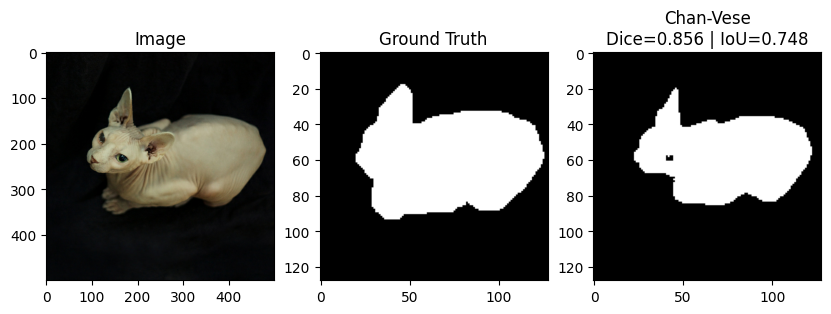

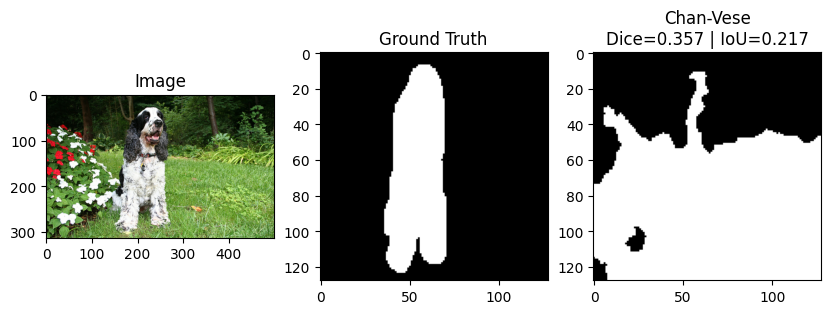

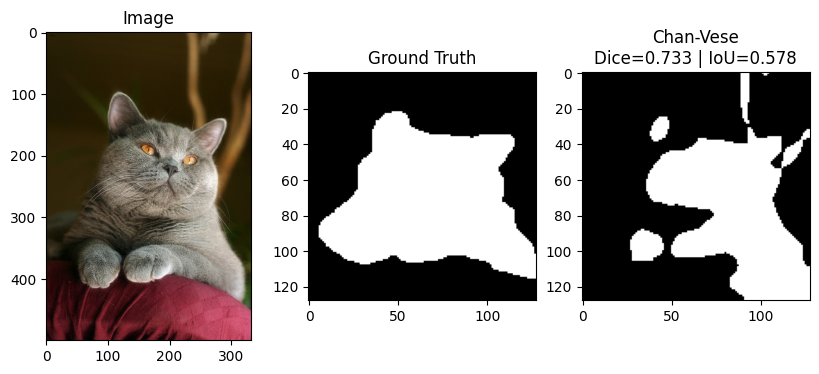

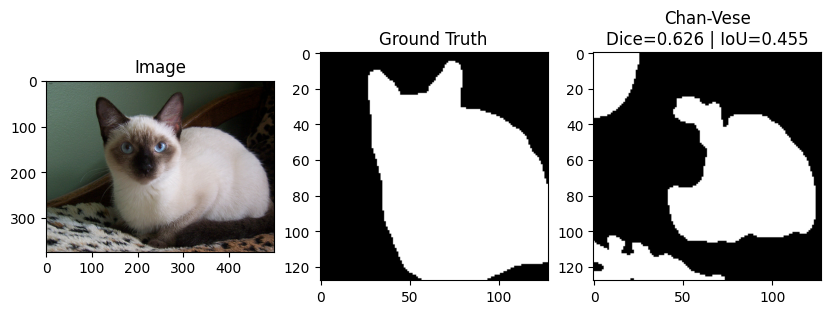

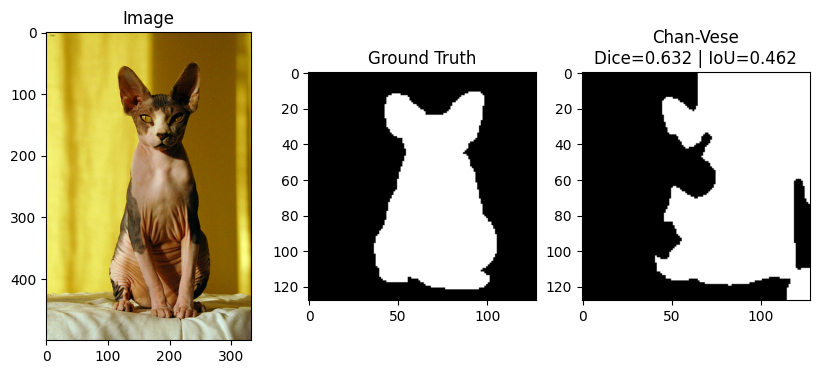

In [ ]:
for i, sample in enumerate(train.take(5)):

    image = sample["image"]
    mask = sample["segmentation_mask"]
    img, gt = preprocess(sample)
    seg = run_chanvese(img)
    d = dice(gt, seg)
    j = iou(gt, seg)
    plt.figure(figsize=(10,4))

    #plt.subplot(1,3,1)
    #plt.imshow(img)
    #plt.title("Image")

    #image originale
    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Image")


    plt.subplot(1,3,2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(seg, cmap="gray")
    plt.title(f"Chan-Vese\nDice={d:.3f} | IoU={j:.3f}")

    plt.show()

In [ ]:
results = []

for sample in train.take(50):
    img_rgb = sample["image"]
    img, mask = preprocess(sample)
    seg = run_chanvese(img)

    # métriques
    d = dice(mask, seg)
    j = iou(mask, seg)

    results.append((d, j))

    print(f"Dice: {d:.3f} | IoU: {j:.3f}")


dice_mean = np.mean([r[0] for r in results])
iou_mean = np.mean([r[1] for r in results])

print("\n=== Métriques d'évaluation ===")
print(f"Dice mean: {dice_mean:.4f}")
print(f"IoU mean: {iou_mean:.4f}")

Dice: 0.856 | IoU: 0.748
Dice: 0.357 | IoU: 0.217
Dice: 0.733 | IoU: 0.578
Dice: 0.626 | IoU: 0.455
Dice: 0.632 | IoU: 0.462
Dice: 0.380 | IoU: 0.235
Dice: 0.777 | IoU: 0.635
Dice: 0.867 | IoU: 0.765
Dice: 0.426 | IoU: 0.270
Dice: 0.495 | IoU: 0.329
Dice: 0.483 | IoU: 0.318
Dice: 0.753 | IoU: 0.604
Dice: 0.672 | IoU: 0.506
Dice: 0.551 | IoU: 0.381
Dice: 0.043 | IoU: 0.022
Dice: 0.582 | IoU: 0.410
Dice: 0.415 | IoU: 0.262
Dice: 0.106 | IoU: 0.056
Dice: 0.602 | IoU: 0.430
Dice: 0.799 | IoU: 0.665
Dice: 0.528 | IoU: 0.359
Dice: 0.049 | IoU: 0.025
Dice: 0.323 | IoU: 0.193
Dice: 0.821 | IoU: 0.697
Dice: 0.486 | IoU: 0.321
Dice: 0.916 | IoU: 0.845
Dice: 0.405 | IoU: 0.254
Dice: 0.119 | IoU: 0.063
Dice: 0.852 | IoU: 0.742
Dice: 0.576 | IoU: 0.405
Dice: 0.887 | IoU: 0.798
Dice: 0.786 | IoU: 0.648
Dice: 0.661 | IoU: 0.494
Dice: 0.789 | IoU: 0.652
Dice: 0.778 | IoU: 0.636
Dice: 0.604 | IoU: 0.433
Dice: 0.441 | IoU: 0.283
Dice: 0.839 | IoU: 0.722
Dice: 0.627 | IoU: 0.457
Dice: 0.469 | IoU: 0.307


In [ ]:
print("mask unique:", np.unique(mask))
print("seg unique:", np.unique(seg))

mask unique: [False  True]
seg unique: [False  True]


Test sur des images synthétiques

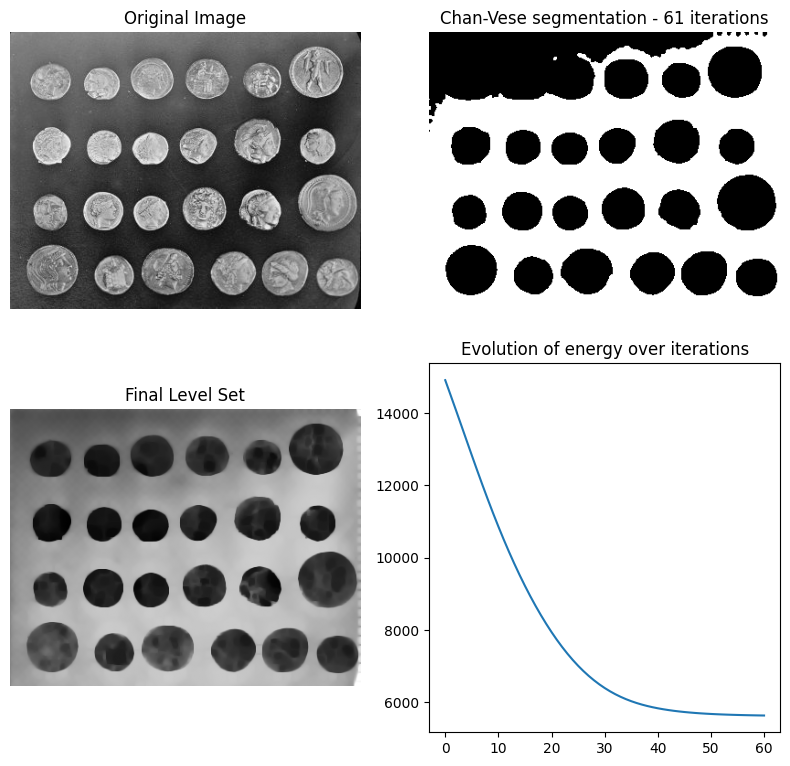

In [ ]:
#image = img_as_float(data.camera())
image = img_as_float(data.coins())
# Feel free to play around with the parameters to see how they impact the result
cv = chan_vese(
    image,
    mu=0.25,
    lambda1=1,
    lambda2=1,
    tol=1e-3,
    max_num_iter=200,
    dt=0.5,
    init_level_set="checkerboard",
    extended_output=True,
)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
ax = axes.flatten()

ax[0].imshow(image, cmap="gray")
ax[0].set_axis_off()
ax[0].set_title("Original Image", fontsize=12)

ax[1].imshow(cv[0], cmap="gray")
ax[1].set_axis_off()
title = f'Chan-Vese segmentation - {len(cv[2])} iterations'
ax[1].set_title(title, fontsize=12)

ax[2].imshow(cv[1], cmap="gray")
ax[2].set_axis_off()
ax[2].set_title("Final Level Set", fontsize=12)

ax[3].plot(cv[2])
ax[3].set_title("Evolution of energy over iterations", fontsize=12)

fig.tight_layout()
plt.show()